In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:

# 1. Leitura dos dados 
df = pd.read_csv('../../assets/raw_courses_data.csv', sep=',', low_memory=False)

# 2. Seleção das colunas com os múltiplos anos de salário
colunas_roi = [
    # Identificação base
    'UNITID','INSTNM', 'CIPCODE', 'CIPDESC', 'CREDLEV', 'IPEDSCOUNT1', 'DISTANCE',
    
    # Dívida Global e Desagregada
    'DEBT_ALL_STGP_ANY_MDN',
    'DEBT_MALE_STGP_ANY_MDN', 'DEBT_NOTMALE_STGP_ANY_MDN',
    'DEBT_PELL_STGP_ANY_MDN', 'DEBT_NOPELL_STGP_ANY_MDN',
    
    # ----------------------------------------------------
    # SALÁRIOS: GLOBAIS
    # ----------------------------------------------------
    'EARN_MDN_1YR', 'EARN_MDN_4YR', 'EARN_MDN_5YR',
    
    # ----------------------------------------------------
    # SALÁRIOS: ANO 1 (Género e Pell)
    # ----------------------------------------------------
    'EARN_MALE_WNE_MDN_1YR', 'EARN_NOMALE_WNE_MDN_1YR',
    'EARN_PELL_WNE_MDN_1YR', 'EARN_NOPELL_WNE_MDN_1YR',
    
    # ----------------------------------------------------
    # SALÁRIOS: ANO 3 (Género e Pell) 
    # ----------------------------------------------------
    'EARN_MALE_NE_MDN_3YR', 'EARN_NOMALE_NE_MDN_3YR',
    'EARN_PELL_NE_MDN_3YR', 'EARN_NOPELL_NE_MDN_3YR',
    
    # ----------------------------------------------------
    # SALÁRIOS: ANO 4 (Género e Pell)
    # ----------------------------------------------------
    'EARN_MALE_WNE_MDN_4YR', 'EARN_NOMALE_WNE_MDN_4YR',
    'EARN_PELL_WNE_MDN_4YR', 'EARN_NOPELL_WNE_MDN_4YR',

    # ----------------------------------------------------
    # SALÁRIOS: ANO 5 (Género e Pell)
    # ----------------------------------------------------
    'EARN_MALE_WNE_MDN_5YR', 'EARN_NOMALE_WNE_MDN_5YR',
    'EARN_PELL_WNE_MDN_5YR', 'EARN_NOPELL_WNE_MDN_5YR',
    
    # Sucesso a pagar a dívida (2 anos depois)
    'BBRR2_FED_COMP_MAKEPROG', 'BBRR2_FED_COMP_DFLT'
]

df_projeto = df[colunas_roi].copy()

# 3. Tratamento de valores ocultos (Privacy)
df_projeto.replace(['PrivacySuppressed', 'PS', 'NULL'], np.nan, inplace=True)
df_projeto.replace(r'^\s*$', np.nan, regex=True, inplace=True) # Limpa espaços em branco invisíveis

# 4. Conversão forçada para numérico em TODAS as colunas financeiras
colunas_para_converter = [
    'DEBT_ALL_STGP_ANY_MDN', 
    'EARN_MDN_1YR', 'EARN_MDN_4YR', 'EARN_MDN_5YR', 
    'IPEDSCOUNT1'
]

for col in colunas_para_converter:
    df_projeto[col] = pd.to_numeric(df_projeto[col], errors='coerce')

# 5. Trata valores inválidos

# A) A linha TEM de ter a informação da dívida geral
df_limpo = df_projeto.dropna(subset=['DEBT_ALL_STGP_ANY_MDN'])

# B) A linha TEM de ter TODOS os anos de salário globais (1, 4 e 5 anos)
df_limpo = df_limpo.dropna(subset=['EARN_MDN_1YR', 'EARN_MDN_4YR', 'EARN_MDN_5YR'], how='any')

# C) A linha TEM de ter TODOS os dados de Género ao longo do tempo (1, 3, 4 e 5 anos)
colunas_genero = [
    'EARN_MALE_WNE_MDN_1YR', 'EARN_NOMALE_WNE_MDN_1YR',
    'EARN_MALE_NE_MDN_3YR', 'EARN_NOMALE_NE_MDN_3YR',
    'EARN_MALE_WNE_MDN_4YR', 'EARN_NOMALE_WNE_MDN_4YR',
    'EARN_MALE_WNE_MDN_5YR', 'EARN_NOMALE_WNE_MDN_5YR'
]
df_limpo = df_limpo.dropna(subset=colunas_genero, how='any')

# D) A linha TEM de ter TODOS os dados de Bolsa Pell ao longo do tempo (1, 3, 4 e 5 anos)
colunas_pell = [
    'EARN_PELL_WNE_MDN_1YR', 'EARN_NOPELL_WNE_MDN_1YR',
    'EARN_PELL_NE_MDN_3YR', 'EARN_NOPELL_NE_MDN_3YR',
    'EARN_PELL_WNE_MDN_4YR', 'EARN_NOPELL_WNE_MDN_4YR',
    'EARN_PELL_WNE_MDN_5YR', 'EARN_NOPELL_WNE_MDN_5YR'
]
df_limpo = df_limpo.dropna(subset=colunas_pell, how='any')

# 6. Guardar os dados e extrair o código da família
df_limpo['CIP_FAMILIA'] = df_limpo['CIPCODE'].astype(str).str.replace(r'\.0', '', regex=True).str.zfill(4).str[:2]

df_limpo.to_csv("../../data/clean_data.csv")
print(f"Nº final de linhas: {len(df_limpo)}")

Nº final de linhas: 5747


In [8]:
cols = ['UNITID', 'LATITUDE', 'LONGITUDE', 'STABBR', 'CITY', 'CONTROL', 'UGDS', 'UGDS_MEN', 'UGDS_WOMEN']
df_geo = pd.read_csv('../../assets/raw_institution_data.csv', usecols=cols)

# Usamos 'left' para garantir que não perdemos nenhum curso do teu dataset original
df_final = pd.merge(df_limpo, df_geo, on='UNITID', how='left')

# 4. Pequeno ajuste: O 'CONTROL' as vezes vem como número, vamos dar nome
df_final = df_final.dropna(subset=['CONTROL'])
mapping_control = {1: 'Pública', 2: 'Privada (s/ fins)', 3: 'Privada (c/ fins)'}
df_final['Tipo_Instituicao'] = df_final['CONTROL'].map(mapping_control)

# 5. Guardar o ficheiro
df_final.to_csv('../../data/merged_data.csv', index=False)

print(f"Dataset pronto! Agora tens localização para {df_final['LATITUDE'].notna().sum()} linhas.")

Dataset pronto! Agora tens localização para 5480 linhas.


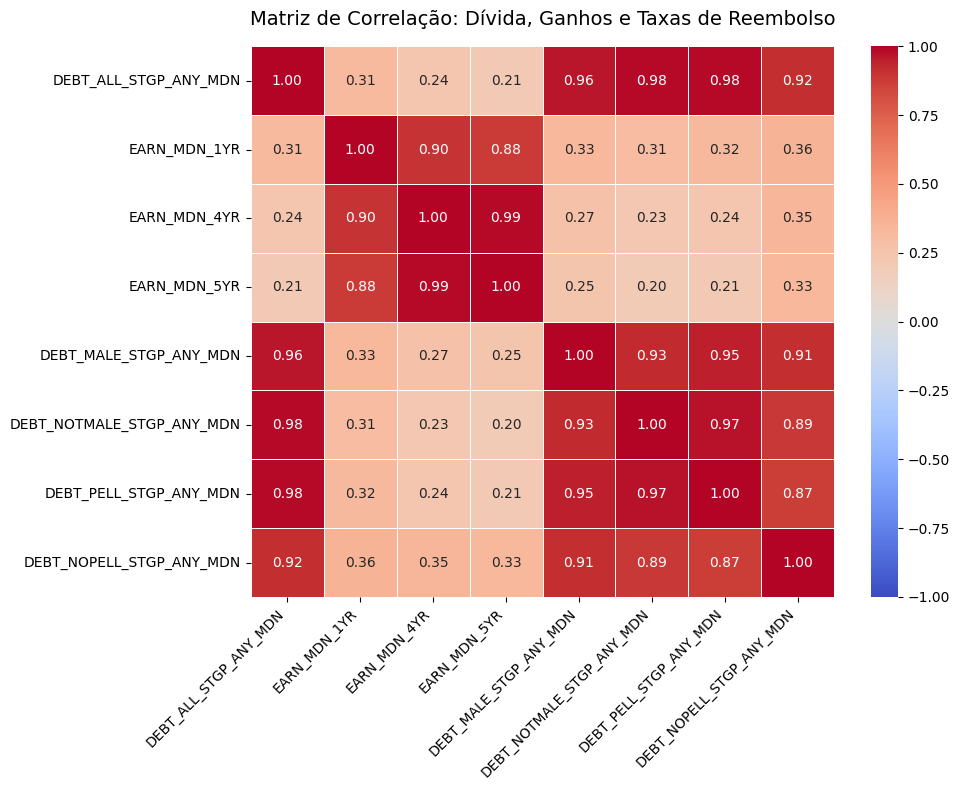

In [6]:
# 1. Carregar o teu dataset limpo
df_final = pd.read_csv('../data/merged_data.csv', sep=',')

# 2. Selecionar apenas as colunas numéricas (financeiras e contagens) para a correlação
colunas_numericas = [
    'DEBT_ALL_STGP_ANY_MDN', 
    'EARN_MDN_1YR', 
    'EARN_MDN_4YR', 
    'EARN_MDN_5YR',
    'DEBT_MALE_STGP_ANY_MDN', 
    'DEBT_NOTMALE_STGP_ANY_MDN',
    'DEBT_PELL_STGP_ANY_MDN', 
    'DEBT_NOPELL_STGP_ANY_MDN'
    #,'BBRR2_FED_COMP_MAKEPROG',
    #'BBRR2_FED_COMP_DFLT'
]

# Filtramos o dataset apenas para estas colunas
colunas_presentes = [col for col in colunas_numericas if col in df_final.columns]
df_corr = df_final[colunas_presentes]

# 3. Calcular a matriz de correlação (Método de Pearson)
matriz_correlacao = df_corr.corr()

# 4. Desenhar o Heatmap com o Seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(
    matriz_correlacao, 
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5, 
    vmin=-1, vmax=1
)

plt.title('Matriz de Correlação: Dívida, Ganhos e Taxas de Reembolso', fontsize=14, pad=15)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [7]:
import plotly.express as px

# 1. Preenchemos os NaNs na contagem de alunos com o valor 1
df_final['IPEDSCOUNT1'] = df_final['IPEDSCOUNT1'].fillna(1)

# 2. CRIAR A COLUNA QUE FALTA (Mapear o CONTROL para Tipo_Instituicao)
mapping_control = {1: 'Pública', 2: 'Privada (Sem Fins)', 3: 'Privada (Com Fins)'}
df_final['Tipo_Instituicao'] = df_final['CONTROL'].map(mapping_control)

# 3. As tuas cores do Canva
cores_setor = {
    'Pública': '#06B6D4',              # Turquesa
    'Privada (Sem Fins)': '#10B981',   # Verde Esmeralda
    'Privada (Com Fins)': '#F43F5E'    # Laranja/Coral
}

# 4. Desenhar o gráfico (A Opção 1: Small Multiples/Facetas)
fig_roi = px.scatter(
    df_final,
    x='DEBT_ALL_STGP_ANY_MDN',
    y='EARN_MDN_4YR',
    size='IPEDSCOUNT1',
    color='Tipo_Instituicao',
    facet_col='Tipo_Instituicao', # Divide em 3 gráficos
    color_discrete_map=cores_setor,
    hover_name='INSTNM',
    size_max=40,
    opacity=0.6,
    title="Q1: A Ilusão do Preço por Setor",
    labels={'DEBT_ALL_STGP_ANY_MDN': 'Dívida ($)', 'EARN_MDN_4YR': 'Salário ($)'}
)

# Limpar o fundo e esconder a legenda
fig_roi.update_layout(
    showlegend=False,
    plot_bgcolor='#FFFFFF',
    paper_bgcolor='#FFFFFF',
    font_color='#1E293B' 
)

fig_roi.show()

In [8]:
import plotly.express as px

# 1. Criação do mapa com nomes em Inglês nos labels
fig_mapa = px.scatter_map(
    df_final, 
    lat="LATITUDE", 
    lon="LONGITUDE", 
    color="EARN_MDN_4YR", 
    size="IPEDSCOUNT1",
    hover_name="INSTNM",
    hover_data={'CIPDESC': True, 'EARN_MDN_4YR': True},
    color_continuous_scale=px.colors.sequential.Plasma,
    size_max=20,
    zoom=3,
    title="Geographic Distribution of Median Earnings", # Título em Inglês
    labels={
        'EARN_MDN_4YR': 'Median Earnings ($)', # Legenda em Inglês
        'IPEDSCOUNT1': 'Number of Students',   # Tamanho em Inglês
        'CIPDESC': 'Field of Study'            # Hover em Inglês
    }
)

# 2. Mover a Colorbar para baixo e configurar o estilo
fig_mapa.update_layout(
    mapbox_style="carto-positron", 
    margin={"r":0,"t":50,"l":0,"b":50}, # Aumentamos a margem inferior (b) para caber a barra
    coloraxis_colorbar=dict(
        title="Median Earnings",
        thicknessmode="pixels", thickness=15,
        lenmode="fraction", len=0.6,
        orientation="h",        # <--- Força a barra a ficar HORIZONTAL
        yanchor="bottom",       # <--- Ancora a barra no fundo
        y=-0.15,                # <--- Posição negativa para sair de dentro do mapa
        xanchor="center", 
        x=0.5
    )
)

fig_mapa.show()

In [9]:
# Simulando o clique do utilizador num curso específico no Dash
curso_selecionado = df_final.iloc[0] # Pega na 1ª linha do dataset como exemplo

# Eixo X (O tempo)
anos = ['Ano 1', 'Ano 3', 'Ano 4', 'Ano 5']

# Eixo Y (Os salários para Pell e No Pell)
salarios_pell = [
    curso_selecionado['EARN_PELL_WNE_MDN_1YR'],
    curso_selecionado['EARN_PELL_NE_MDN_3YR'],
    curso_selecionado['EARN_PELL_WNE_MDN_4YR'],
    curso_selecionado['EARN_PELL_WNE_MDN_5YR']
]

salarios_nopell = [
    curso_selecionado['EARN_NOPELL_WNE_MDN_1YR'],
    curso_selecionado['EARN_NOPELL_NE_MDN_3YR'],
    curso_selecionado['EARN_NOPELL_WNE_MDN_4YR'],
    curso_selecionado['EARN_NOPELL_WNE_MDN_5YR']
]

# Construção do gráfico com Graph Objects (melhor para linhas duplas manuais)
fig_trajetoria = go.Figure()

fig_trajetoria.add_trace(go.Scatter(x=anos, y=salarios_pell, mode='lines+markers', name='Alunos c/ Bolsa Pell (Baixo Rendimento)'))
fig_trajetoria.add_trace(go.Scatter(x=anos, y=salarios_nopell, mode='lines+markers', name='Alunos s/ Bolsa Pell (Alto Rendimento)'))

fig_trajetoria.update_layout(
    title=f"Evolução Salarial: {curso_selecionado['INSTNM']} - {curso_selecionado['CIPDESC']}",
    yaxis_title="Salário Mediano ($)",
    hovermode="x unified"
)

fig_trajetoria.show()

In [10]:
import plotly.express as px
import plotly.graph_objects as go

# 1. Recriar a coluna com os nomes bonitos a partir do 'CONTROL'
mapping_control = {1: 'Pública', 2: 'Privada (Sem Fins)', 3: 'Privada (Com Fins)'}
df_final['Tipo_Instituicao'] = df_final['CONTROL'].map(mapping_control)

# 2. Agora sim, desenhar o Boxplot
fig_box = px.box(
    df_final,
    x="Tipo_Instituicao",
    y="DEBT_ALL_STGP_ANY_MDN",
    color="Tipo_Instituicao",
    title="Distribuição do Nível de Endividamento por Tipo de Instituição",
    labels={
        'Tipo_Instituicao': 'Setor',
        'DEBT_ALL_STGP_ANY_MDN': 'Dívida Mediana dos Alunos ($)'
    },
    points="outliers" 
)

fig_box.show()

In [11]:
import plotly.express as px

# 2. Criar o Donut Chart
fig_donut = px.pie(
    df_final, 
    values='IPEDSCOUNT1',
    names='Tipo_Instituicao',
    title='Quota de Mercado',
    hole=0.45,
    color='Tipo_Instituicao',
    # AS MESMAS CORES:
    color_discrete_map={
        'Pública': '#06B6D4',
        'Privada (Sem Fins)': '#10B981',
        'Privada (Com Fins)': '#F43F5E'
    }
)

fig_donut.update_layout(paper_bgcolor='#FFFFFF', font_color='#1E293B')
fig_donut.show()

In [13]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import numpy as np

# 1. Carregar os dados que preparaste
df_final = pd.read_csv('../data/merged_data.csv', low_memory=False)

# 2. Preparação Visual e de Cálculos (Mesmo passo que usaste no Canva)
df_final['IPEDSCOUNT1'] = df_final['IPEDSCOUNT1'].fillna(1) # Impede erro do tamanho das bolhas

# As cores que definimos no Canva para consistência visual
cores_setor = {
    'Pública': '#06B6D4', 
    'Privada (Sem Fins)': '#10B981', 
    'Privada (Com Fins)': '#F43F5E'
}

# ----------------------------------------------------------------------
# Q1. A Ilusão do Preço: Dívida vs. Salário (Radar de ROI)
# ----------------------------------------------------------------------
fig_q1 = px.scatter(
    df_final,
    x='DEBT_ALL_STGP_ANY_MDN',
    y='EARN_MDN_4YR',
    size='IPEDSCOUNT1',
    color='Tipo_Instituicao',
    color_discrete_map=cores_setor,
    hover_name='INSTNM',
    hover_data={'CIPDESC': True, 'STABBR': True},
    size_max=50,
    opacity=0.7,
    title="Q1: A Ilusão do Preço (Dívida Mediana vs. Salário a 4 Anos)",
    labels={
        'DEBT_ALL_STGP_ANY_MDN': 'Dívida Mediana ($)',
        'EARN_MDN_4YR': 'Salário Mediano a 4 Anos ($)',
        'Tipo_Instituicao': 'Setor'
    }
)
fig_q1.update_layout(plot_bgcolor='#F8FAFC', paper_bgcolor='#FFFFFF')
fig_q1.show()

fig_q1_op1 = px.scatter(
    df_final,
    x='DEBT_ALL_STGP_ANY_MDN',
    y='EARN_MDN_4YR',
    size='IPEDSCOUNT1',
    color='Tipo_Instituicao',
    facet_col='Tipo_Instituicao',
    color_discrete_map=cores_setor,
    hover_name='INSTNM',
    size_max=40, # Reduzi um pouco o tamanho máximo para os painéis mais pequenos
    opacity=0.6, # Reduzi um pouco mais a opacidade
    title="Q1: A Ilusão do Preço por Setor",
    labels={'DEBT_ALL_STGP_ANY_MDN': 'Dívida Mediana ($)', 'EARN_MDN_4YR': 'Salário 4 Anos ($)'}
)
# Esconder a legenda, já que os títulos de cada coluna já dizem o setor
fig_q1_op1.update_layout(showlegend=False, plot_bgcolor='#F8FAFC', paper_bgcolor='#FFFFFF')
fig_q1_op1.show()

fig_q1_op2 = px.scatter(
    df_final,
    x='DEBT_ALL_STGP_ANY_MDN',
    y='EARN_MDN_4YR',
    size='IPEDSCOUNT1',
    color='Tipo_Instituicao',
    color_discrete_map=cores_setor,
    hover_name='INSTNM',
    size_max=50,
    opacity=0.6,
    marginal_x="histogram", # ADICIONA UM HISTOGRAMA NO TOPO
    marginal_y="violin",    # ADICIONA UM VIOLIN PLOT NA LATERAL
    title="Q1: A Ilusão do Preço (com Distribuição Marginal)",
    labels={'DEBT_ALL_STGP_ANY_MDN': 'Dívida ($)', 'EARN_MDN_4YR': 'Salário ($)', 'Tipo_Instituicao': 'Setor'}
)
fig_q1_op2.update_layout(plot_bgcolor='#F8FAFC', paper_bgcolor='#FFFFFF')
fig_q1_op2.show()

df_final['EARN_MDN_4YR'] = pd.to_numeric(df_final['EARN_MDN_4YR'], errors='coerce')
df_final['DEBT_ALL_STGP_ANY_MDN'] = pd.to_numeric(df_final['DEBT_ALL_STGP_ANY_MDN'], errors='coerce')

# Calcular o Rácio de ROI (Salário / Dívida)
df_final['ROI_Ratio'] = df_final['EARN_MDN_4YR'] / df_final['DEBT_ALL_STGP_ANY_MDN']

# 2. Criação do Mapa com nomes em Inglês nos labels
fig_q2 = px.scatter_map(
    df_final, 
    lat="LATITUDE", 
    lon="LONGITUDE", 
    color="ROI_Ratio",            # <--- Agora focado no Rácio de ROI
    size="IPEDSCOUNT1",
    hover_name="INSTNM",
    # Hover mais completo para explicar o ROI
    hover_data={
        'CIPDESC': True, 
        'EARN_MDN_4YR': ':.2f', # Formata salário no hover
        'DEBT_ALL_STGP_ANY_MDN': ':.2f', # Formata dívida no hover
        'ROI_Ratio': ':.2f' # Formata o rácio
    },
    color_continuous_scale=px.colors.sequential.Viridis,
    size_max=20,
    zoom=3,
    # Título em Inglês
    title="Q2: Geographic Impact (ROI Ratio by Institution)", 
    # Labels em Inglês (o segredo para traduzir a legenda e hover)
    labels={
        'ROI_Ratio': 'ROI Ratio (Salary/Debt)', # Legenda da Colorbar
        'EARN_MDN_4YR': 'Median Earnings ($)',
        'DEBT_ALL_STGP_ANY_MDN': 'Median Debt ($)',
        'IPEDSCOUNT1': 'Number of Students',
        'CIPDESC': 'Field of Study'
    }
)

# 3. Mover a Colorbar (Legenda de ROI) para baixo e configurar o estilo
fig_q2.update_layout(
    mapbox_style="carto-positron", 
    # Aumentamos a margem inferior (b) para caber a barra
    margin={"r":0,"t":50,"l":0,"b":80}, 
    coloraxis_colorbar=dict(
        title="ROI Ratio",
        thicknessmode="pixels", thickness=15,
        lenmode="fraction", len=0.7,
        orientation="h",        # <--- Força a barra a ficar HORIZONTAL
        yanchor="bottom",       # <--- Ancora a barra no fundo
        y=-0.25,                # <--- Empurra para baixo do mapa
        xanchor="center", 
        x=0.5
    )
)

fig_q2.show()

# ----------------------------------------------------------------------
# Q3. Desigualdade Estrutural: Fosso Salarial de Género
# ----------------------------------------------------------------------
# Escolhemos a primeira linha do dataset como exemplo de "Dossier Institucional"
# Temos de garantir que é lido como numérico.
curso_alvo = df_final.iloc[0].copy()

anos = ['Ano 1', 'Ano 3', 'Ano 4', 'Ano 5']

salarios_homens = pd.to_numeric([
    curso_alvo['EARN_MALE_WNE_MDN_1YR'], curso_alvo['EARN_MALE_NE_MDN_3YR'],
    curso_alvo['EARN_MALE_WNE_MDN_4YR'], curso_alvo['EARN_MALE_WNE_MDN_5YR']
], errors='coerce')

salarios_mulheres = pd.to_numeric([
    curso_alvo['EARN_NOMALE_WNE_MDN_1YR'], curso_alvo['EARN_NOMALE_NE_MDN_3YR'],
    curso_alvo['EARN_NOMALE_WNE_MDN_4YR'], curso_alvo['EARN_NOMALE_WNE_MDN_5YR']
], errors='coerce')

fig_q3 = go.Figure()
fig_q3.add_trace(go.Scatter(x=anos, y=salarios_homens, mode='lines+markers', name='Homens', line=dict(color='#2563EB', width=3)))
fig_q3.add_trace(go.Scatter(x=anos, y=salarios_mulheres, mode='lines+markers', name='Mulheres', line=dict(color='#F43F5E', width=3)))

fig_q3.update_layout(
    title=f"Q3: Desigualdade de Género - {curso_alvo['INSTNM']} ({curso_alvo['CIPDESC']})",
    yaxis_title="Salário Mediano ($)",
    plot_bgcolor='#F8FAFC', 
    paper_bgcolor='#FFFFFF',
    hovermode="x unified"
)
fig_q3.show()

# ----------------------------------------------------------------------
# Q4. Risco de Incumprimento: Default Rate por Área de Estudo
# ----------------------------------------------------------------------
# Converter o Default Rate para numérico
df_final['BBRR2_FED_COMP_DFLT'] = pd.to_numeric(df_final['BBRR2_FED_COMP_DFLT'], errors='coerce')

# Ordenar por mediana decrescente para ficar fácil de ler no Dash
fig_q4 = px.box(
    df_final,
    x="CIP_FAMILIA",
    y="BBRR2_FED_COMP_DFLT",
    color="CIP_FAMILIA",
    title="Q4: Risco de Incumprimento (Default Rate) por Família de Curso",
    labels={
        'CIP_FAMILIA': 'Família do Curso (Código CIP)',
        'BBRR2_FED_COMP_DFLT': 'Taxa de Incumprimento'
    },
    points="outliers"
)
fig_q4.update_layout(
    xaxis={'categoryorder':'median descending'},
    showlegend=False, 
    plot_bgcolor='#F8FAFC', 
    paper_bgcolor='#FFFFFF'
)
fig_q4.show()

# ----------------------------------------------------------------------
# BÓNUS: Distribuição de Género (O novo gráfico do painel lateral da Página 2)
# ----------------------------------------------------------------------
valores_demograficos = pd.to_numeric([curso_alvo['UGDS_MEN'], curso_alvo['UGDS_WOMEN']], errors='coerce')

fig_demo = px.pie(
    values=valores_demograficos, 
    names=['Homens', 'Mulheres'], 
    title=f"Demografia Global: {curso_alvo['INSTNM']}",
    hole=0.4,
    color_discrete_sequence=['#2563EB', '#F43F5E']
)
fig_demo.update_traces(textinfo='percent+label')
fig_demo.update_layout(paper_bgcolor='#FFFFFF')
fig_demo.show()

# Só calcula se o DataFrame não estiver vazio
if not df_final.empty:
    # 1. TOTAL DE ALUNOS (Soma da coluna de contagem)
    # Usamos .sum() e formatamos com f-string para ter separador de milhar
    total_alunos_val = int(df_final['IPEDSCOUNT1'].sum())
    total_alunos_formatado = f"{total_alunos_val:,}".replace(",", ".") # Padrão PT-BR

    # 2. DÍVIDA MEDIANA (Média das medianas ou mediana global)
    divida_val = df_final['DEBT_ALL_STGP_ANY_MDN'].median()
    divida_formatada = f"$ {divida_val:,.0f}".replace(",", "X").replace(".", ",").replace("X", ".")

    # 3. SALÁRIO MEDIANO (4 ANOS)
    salario_val = df_final['EARN_MDN_4YR'].median()
    salario_formatado = f"$ {salario_val:,.0f}".replace(",", "X").replace(".", ",").replace("X", ".")
else:
    # Valores padrão caso o arquivo não carregue
    total_alunos_formatado = "0"
    divida_formatada = "$ 0"
    salario_formatado = "$ 0"